# WTI Price Autocorrelation — Prior vs Future Returns

Does this week's price return predict next week's?
Is there momentum or mean-reversion in WTI weekly returns?

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.append('../../../../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load daily prices and compute weekly returns

In [2]:
prices = pd.read_csv('../../../../cache/preprocessed_data/wti_prices_panel.csv',
                      usecols=['tradeDate', 'F1_RolledPrice'])
prices['tradeDate'] = pd.to_datetime(prices['tradeDate'])
prices.sort_values('tradeDate', inplace=True)
prices.reset_index(drop=True, inplace=True)

# Weekly returns: Friday-to-Friday
fridays = prices[prices['tradeDate'].dt.dayofweek == 4].copy()
fridays['weekly_ret'] = fridays['F1_RolledPrice'].pct_change() * 100
fridays.dropna(subset=['weekly_ret'], inplace=True)
fridays.reset_index(drop=True, inplace=True)

print(f'Weekly returns: {len(fridays)} Fridays')
print(f'Range: {fridays["tradeDate"].min().date()} -> {fridays["tradeDate"].max().date()}')
print(f'Mean: {fridays["weekly_ret"].mean():.3f}%, Std: {fridays["weekly_ret"].std():.3f}%')

Weekly returns: 786 Fridays
Range: 2010-01-15 -> 2025-08-01
Mean: 1.471%, Std: 37.781%


## 2. Autocorrelation function

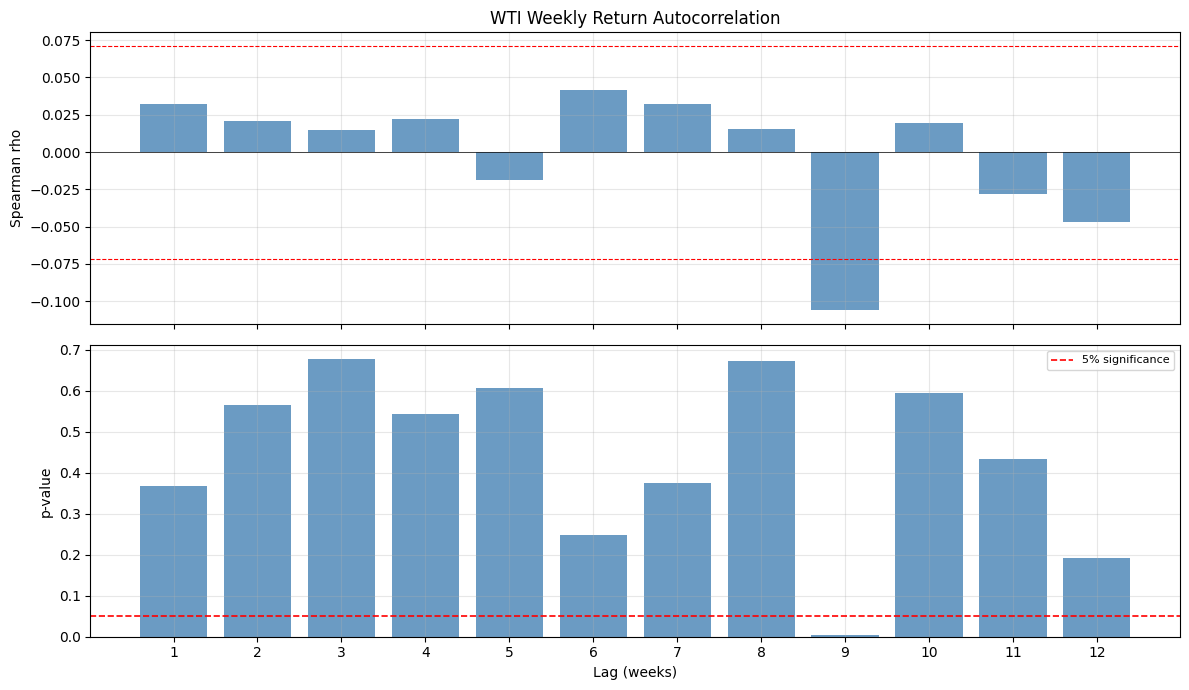

 Lag       rho       p-val
----------------------------
   1   +0.032       3.7e-01
   2   +0.021       5.7e-01
   3   +0.015       6.8e-01
   4   +0.022       5.4e-01
   5   -0.019       6.1e-01
   6   +0.041       2.5e-01
   7   +0.032       3.7e-01
   8   +0.015       6.7e-01
   9   -0.106 *     3.1e-03
  10   +0.019       5.9e-01
  11   -0.028       4.3e-01
  12   -0.047       1.9e-01


In [3]:
MAX_LAG = 12
ret = fridays['weekly_ret'].values

lags = list(range(1, MAX_LAG + 1))
rhos, pvals = [], []
for k in lags:
    rho, p = sp_stats.spearmanr(ret[:-k], ret[k:])
    rhos.append(rho)
    pvals.append(p)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.bar(lags, rhos, color='steelblue', alpha=0.8)
ax.axhline(0, color='black', lw=0.5)
sig = 2 / np.sqrt(len(ret))
ax.axhline(sig, color='red', linestyle='--', lw=0.8)
ax.axhline(-sig, color='red', linestyle='--', lw=0.8)
ax.set_ylabel('Spearman rho')
ax.set_title('WTI Weekly Return Autocorrelation')

ax = axes[1]
ax.bar(lags, pvals, color='steelblue', alpha=0.8)
ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% significance')
ax.set_ylabel('p-value')
ax.set_xlabel('Lag (weeks)')
ax.set_xticks(lags)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'{"Lag":>4s}  {"rho":>8s}  {"p-val":>10s}')
print('-' * 28)
for k, r, p in zip(lags, rhos, pvals):
    s = '*' if p < 0.05 else ' '
    print(f'{k:>4d}  {r:>+7.3f} {s}  {p:>10.1e}')

## 3. 5-year blocks

In [4]:
fridays['year'] = fridays['tradeDate'].dt.year

blocks_5y = [
    ('2010-2014', (2010, 2014)),
    ('2015-2019', (2015, 2019)),
    ('2020-2025', (2020, 2025)),
]

KEY_LAGS = [1, 2, 3, 4, 8, 12]
print(f'{"Block":>12s}  {"n":>4s}', end='')
for k in KEY_LAGS:
    print(f'  lag {k:>2d}', end='')
print()
print('-' * (22 + 8 * len(KEY_LAGS)))

for label, (y_start, y_end) in blocks_5y + [('Full sample', (2010, 2025))]:
    sub = fridays[(fridays['year'] >= y_start) & (fridays['year'] <= y_end)]
    r = sub['weekly_ret'].values
    print(f'{label:>12s}  {len(sub):>4d}', end='')
    for k in KEY_LAGS:
        if len(r) > k:
            rho, _ = sp_stats.spearmanr(r[:-k], r[k:])
        else:
            rho = float('nan')
        print(f'  {rho:>+6.3f}', end='')
    print()

       Block     n  lag  1  lag  2  lag  3  lag  4  lag  8  lag 12
----------------------------------------------------------------------
   2010-2014   252  +0.016  +0.019  -0.033  +0.036  +0.014  -0.059
   2015-2019   253  +0.051  +0.023  -0.020  -0.089  +0.004  -0.129
   2020-2025   281  -0.000  +0.006  +0.032  +0.094  +0.016  -0.004
 Full sample   786  +0.032  +0.021  +0.015  +0.022  +0.015  -0.047


## 4. 3-year blocks

In [5]:
blocks_3y = [
    ('2010-2012', (2010, 2012)),
    ('2013-2015', (2013, 2015)),
    ('2016-2018', (2016, 2018)),
    ('2019-2021', (2019, 2021)),
    ('2022-2025', (2022, 2025)),
]

print(f'{"Block":>12s}  {"n":>4s}', end='')
for k in KEY_LAGS:
    print(f'  lag {k:>2d}', end='')
print()
print('-' * (22 + 8 * len(KEY_LAGS)))

for label, (y_start, y_end) in blocks_3y + [('Full sample', (2010, 2025))]:
    sub = fridays[(fridays['year'] >= y_start) & (fridays['year'] <= y_end)]
    r = sub['weekly_ret'].values
    print(f'{label:>12s}  {len(sub):>4d}', end='')
    for k in KEY_LAGS:
        if len(r) > k:
            rho, _ = sp_stats.spearmanr(r[:-k], r[k:])
        else:
            rho = float('nan')
        print(f'  {rho:>+6.3f}', end='')
    print()

       Block     n  lag  1  lag  2  lag  3  lag  4  lag  8  lag 12
----------------------------------------------------------------------
   2010-2012   151  -0.033  -0.003  -0.059  -0.024  +0.041  -0.088
   2013-2015   150  +0.157  +0.078  +0.088  +0.133  +0.063  -0.003
   2016-2018   153  +0.060  -0.020  -0.110  -0.053  -0.048  -0.057
   2019-2021   150  +0.010  +0.093  -0.028  +0.070  +0.135  -0.042


   2022-2025   182  -0.094  -0.104  +0.105  +0.027  -0.062  -0.023
 Full sample   786  +0.032  +0.021  +0.015  +0.022  +0.015  -0.047


## 5. 2-year blocks

In [6]:
blocks_2y = [
    ('2010-2011', (2010, 2011)),
    ('2012-2013', (2012, 2013)),
    ('2014-2015', (2014, 2015)),
    ('2016-2017', (2016, 2017)),
    ('2018-2019', (2018, 2019)),
    ('2020-2021', (2020, 2021)),
    ('2022-2023', (2022, 2023)),
    ('2024-2025', (2024, 2025)),
]

print(f'{"Block":>12s}  {"n":>4s}', end='')
for k in KEY_LAGS:
    print(f'  lag {k:>2d}', end='')
print()
print('-' * (22 + 8 * len(KEY_LAGS)))

for label, (y_start, y_end) in blocks_2y + [('Full sample', (2010, 2025))]:
    sub = fridays[(fridays['year'] >= y_start) & (fridays['year'] <= y_end)]
    r = sub['weekly_ret'].values
    print(f'{label:>12s}  {len(sub):>4d}', end='')
    for k in KEY_LAGS:
        if len(r) > k:
            rho, _ = sp_stats.spearmanr(r[:-k], r[k:])
        else:
            rho = float('nan')
        print(f'  {rho:>+6.3f}', end='')
    print()

       Block     n  lag  1  lag  2  lag  3  lag  4  lag  8  lag 12
----------------------------------------------------------------------
   2010-2011   100  -0.044  -0.054  -0.071  -0.085  +0.032  -0.044
   2012-2013   102  +0.038  +0.051  -0.017  +0.081  -0.152  -0.134
   2014-2015    99  +0.184  +0.116  +0.156  +0.176  +0.135  +0.029
   2016-2017   102  +0.002  -0.005  -0.198  -0.110  -0.087  -0.109
   2018-2019   102  -0.004  -0.026  +0.062  -0.125  +0.030  -0.161
   2020-2021    99  +0.040  +0.088  -0.088  +0.144  +0.112  -0.036
   2022-2023   102  -0.012  -0.168  +0.077  +0.187  -0.034  -0.050
   2024-2025    80  -0.262  -0.021  +0.137  -0.223  -0.110  +0.062
 Full sample   786  +0.032  +0.021  +0.015  +0.022  +0.015  -0.047


## 6. Rolling 104-week autocorrelation at key lags

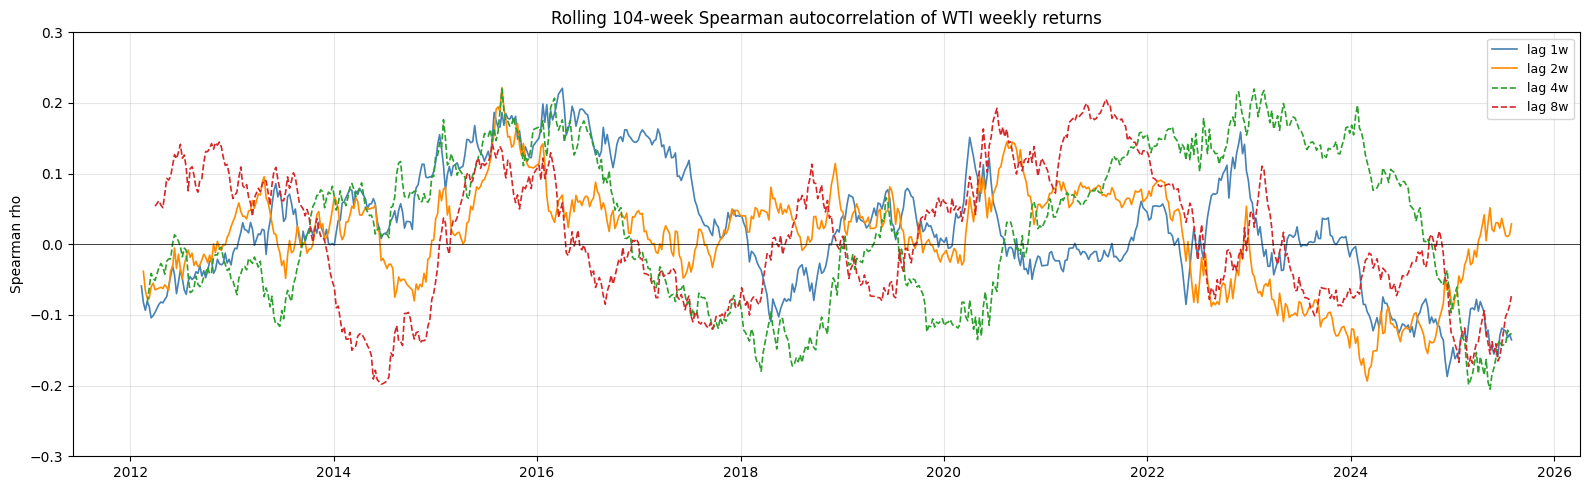

In [7]:
WINDOW = 104

fig, ax = plt.subplots(figsize=(16, 5))
for k, color, ls in [(1, 'steelblue', '-'), (2, 'darkorange', '-'),
                       (4, 'tab:green', '--'), (8, 'tab:red', '--')]:
    rhos_roll = []
    for i in range(len(ret)):
        if i < WINDOW + k:
            rhos_roll.append(np.nan)
        else:
            rho, _ = sp_stats.spearmanr(ret[i-WINDOW-k:i-k], ret[i-WINDOW:i])
            rhos_roll.append(rho)
    ax.plot(fridays['tradeDate'], rhos_roll, label=f'lag {k}w',
            color=color, linestyle=ls, lw=1.2)

ax.axhline(0, color='black', lw=0.5)
ax.set_title(f'Rolling {WINDOW}-week Spearman autocorrelation of WTI weekly returns')
ax.set_ylabel('Spearman rho')
ax.set_ylim(-0.3, 0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()